# Hands on Exploratory Data Analysis First in Python 

## By Johannes Simatupang M.Kom.,COBIT5 (Feb 2024)

COMP6577 - Machine Learning >>> Bina Nusantara University

In [22]:
#Loading Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
#Loading Dataset from sklearn
from sklearn.datasets import load_diabetes
# LOADING DIABETES DATA (INPUT FEATURES) AND STORING IT IN A DATA FRAME
data = pd.DataFrame(load_diabetes()["data"],columns=load_diabetes()["feature_names"])
#ADDING TARGET VARIABLE TO THE DATA FRAME
data["target"] = load_diabetes()["target"]

### 1. Find the dimensions of the dataset

In [24]:
# 1. Find the dimensions of the dataset
data.shape

(442, 11)

### 2. Look at first few records of the dataset

In [25]:
# 2. Look at first few records of the dataset
data.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


### 3. Look at the feature names

In [26]:
# 3. Look at the feature names
list(data.columns)

['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6', 'target']

### 4. Look at the data types of the features

In [27]:
# 4. Look at the data types of the features
data.dtypes

age       float64
sex       float64
bmi       float64
bp        float64
s1        float64
s2        float64
s3        float64
s4        float64
s5        float64
s6        float64
target    float64
dtype: object

### 5. Encode Sex

In [28]:
# Encode Sex
data.loc[data["sex"]>0,"sex"] = 1
data.loc[data["sex"]<0,"sex"] = 0
data.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,1.0,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,0.0,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,1.0,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,0.0,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,0.0,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


### 5. Look at statistical summary of the features

In [29]:
# 5. Look at statistical summary of the features
data.describe().T # or data.describe().T

,count,mean,std,min,25%,50%,75%,max
age,442.0,-2.511817e-19,0.047619,-0.107226,-0.037299,0.005383,0.038076,0.110727
sex,442.0,4.683258e-01,0.499561,0.000000,0.000000,0.000000,1.000000,1.000000
bmi,442.0,-2.245564e-16,0.047619,-0.090275,-0.034229,-0.007284,0.031248,0.170555
bp,442.0,-4.797570e-17,0.047619,-0.112399,-0.036656,-0.005670,0.035644,0.132044
s1,442.0,-1.381499e-17,0.047619,-0.126781,-0.034248,-0.004321,0.028358,0.153914
s2,442.0,3.918434e-17,0.047619,-0.115613,-0.030358,-0.003819,0.029844,0.198788
s3,442.0,-5.777179e-18,0.047619,-0.102307,-0.035117,-0.006584,0.029312,0.181179
s4,442.0,-9.042540e-18,0.047619,-0.076395,-0.039493,-0.002592,0.034309,0.185234
s5,442.0,9.293722e-17,0.047619,-0.126097,-0.033246,-0.001947,0.032432,0.133597
s6,442.0,1.130318e-17,0.047619,-0.137767,-0.033179,-0.001078,0.027917,0.135612


### 6. Store the numeric, categorical & target features names in separate variables

In [30]:
# 6. Store the numeric, categorical & target features names in separate variables
# Convert Data Type Sex from float to int
data["sex"] = data["sex"].astype(np.int8)
data.dtypes

age       float64
sex          int8
bmi       float64
bp        float64
s1        float64
s2        float64
s3        float64
s4        float64
s5        float64
s6        float64
target    float64
dtype: object

In [31]:
numeric_features = list(data.select_dtypes("float64").columns)
numeric_features.remove('target')
categorical_features = list(data.select_dtypes("int8").columns)
target = "target"
print(f'numeric_features:\n{numeric_features}\n\ncategorical_features:\n{categorical_features}\n\ntarget:\n{target}')

numeric_features:
['age', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

categorical_features:
['sex']

target:
target


### 7. Look for missing values in the features

In [32]:
# 7. Look for missing values in the features
np.round(data.isnull().mean() * 100,1)

age       0.0
sex       0.0
bmi       0.0
bp        0.0
s1        0.0
s2        0.0
s3        0.0
s4        0.0
s5        0.0
s6        0.0
target    0.0
dtype: float64

No feature has missing values.

### 8. Looking at relative frequencies of values of categorical features

In [33]:
#8. Looking at relative frequencies of values of categorical features
for i in categorical_features:
    print(f'{i}\n{np.round((data[i].value_counts() / data[i].value_counts().sum()) * 100,2)}')

sex
sex
0    53.17
1    46.83
Name: count, dtype: float64


### 9. Looking at distributions of numeric features

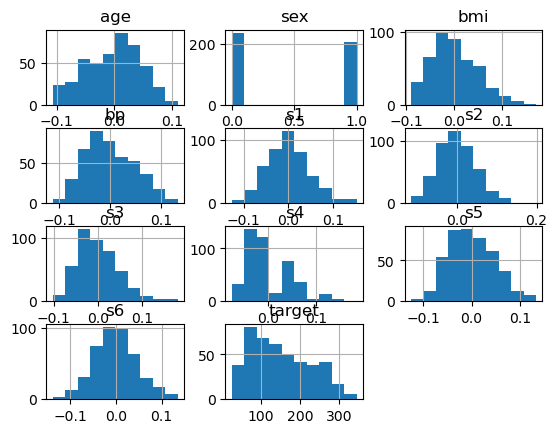

In [34]:
# 9. Looking at distributions of numeric features
# create histogram for numeric data
data.hist()
 
# show plot
plt.show()

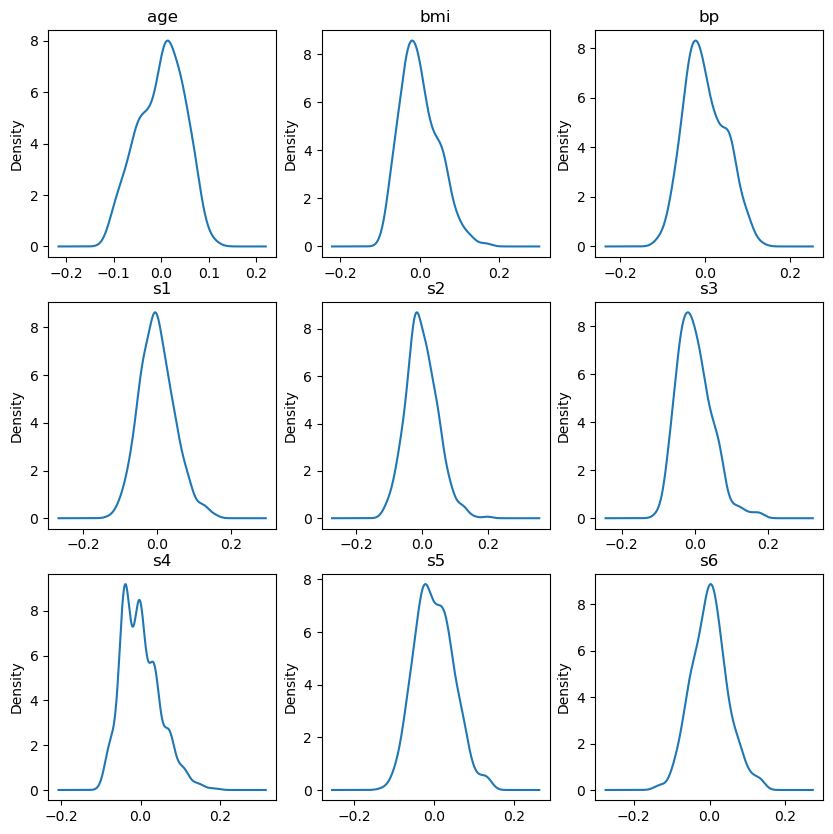

In [35]:
# 9. Looking at distributions of numeric features
fig,ax = plt.subplots(3,3,figsize=(10,10))
row = col = 0
for n,i in enumerate(numeric_features):
    if (n%3 == 0) & (n > 0):
        row += 1
        col = 0
    data[i].plot(kind="kde",ax=ax[row,col])
    ax[row,col].set_title(i)
    col += 1

In [36]:
from scipy.stats import normaltest
for i in numeric_features:
    print(f'{i}: {"Not Gaussian" if normaltest(data[i].values,)[1]<0.05 else "Gaussian"}  {normaltest(data[i].values)}')

age: Not Gaussian  NormaltestResult(statistic=22.98072738269563, pvalue=1.0228182153991939e-05)
bmi: Not Gaussian  NormaltestResult(statistic=23.665619193944938, pvalue=7.262331793832974e-06)
bp: Not Gaussian  NormaltestResult(statistic=15.621391258402692, pvalue=0.00040537595836253937)
s1: Not Gaussian  NormaltestResult(statistic=11.20852755493566, pvalue=0.003682130413975528)
s2: Not Gaussian  NormaltestResult(statistic=18.031282903684225, pvalue=0.00012149451358987423)
s3: Not Gaussian  NormaltestResult(statistic=47.88065264242984, pvalue=4.0072679573118316e-11)
s4: Not Gaussian  NormaltestResult(statistic=36.314360987185864, pvalue=1.3014776207788022e-08)
s5: Not Gaussian  NormaltestResult(statistic=6.462738215551416, pvalue=0.039503377366703625)
s6: Gaussian  NormaltestResult(statistic=4.295701660173062, pvalue=0.11673477122976575)


### 10. Looking at relative standard deviation values with the median

In [37]:
# 10. Looking at relative standard deviation values with the median
for i in numeric_features:
    print(f'{i}: {np.abs(np.round((data[i].std()/data[i].median()) * 100,2))}')

age: 884.61
bmi: 653.77
bp: 839.78
s1: 1102.07
s2: 1246.88
s3: 723.2
s4: 1836.97
s5: 2445.55
s6: 4418.59


### 11. Looking at the target feature’ statistics

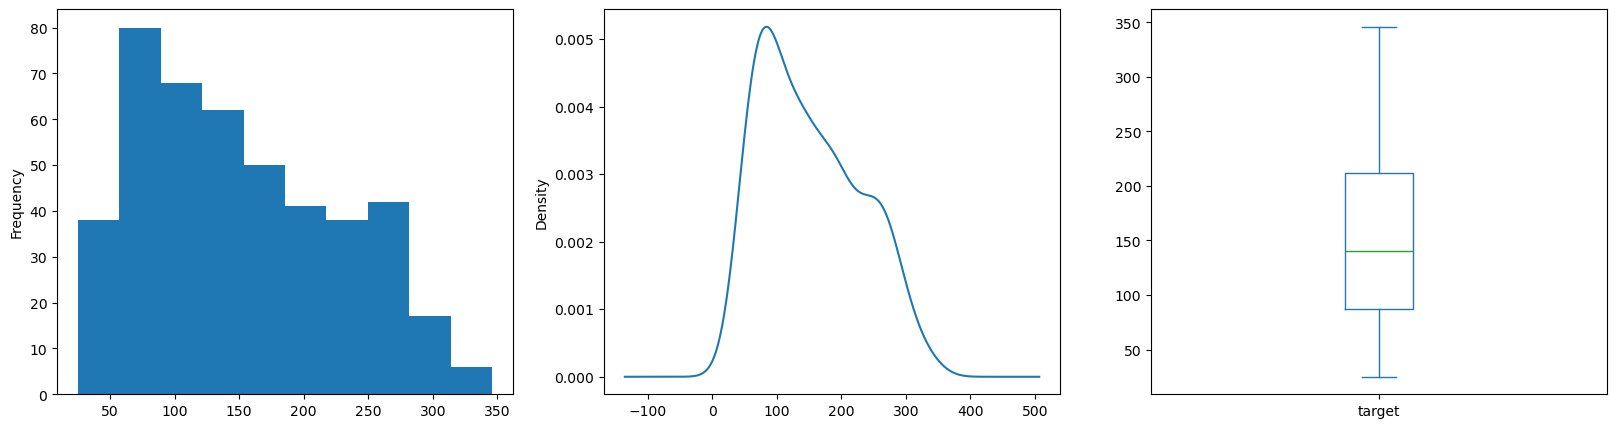

target: Not Gaussian  NormaltestResult(statistic=64.15092254678288, pvalue=1.1743678801847827e-14)


In [38]:
# 11. Looking at the target feature’ statistics
fig,ax = plt.subplots(1,3,figsize=(20,5))
data[target].plot(kind="hist",ax=ax[0])
data[target].plot(kind="kde",ax=ax[1])
data[target].plot(kind="box",ax=ax[2])
plt.show()
print(f'{target}: {"Not Gaussian" if normaltest(data[target].values,)[1]<0.05 else "Gaussian"}  {normaltest(data[target].values)}')

### 12. Looking at the relationship between categorical and target features

<Axes: xlabel='sex', ylabel='target'>

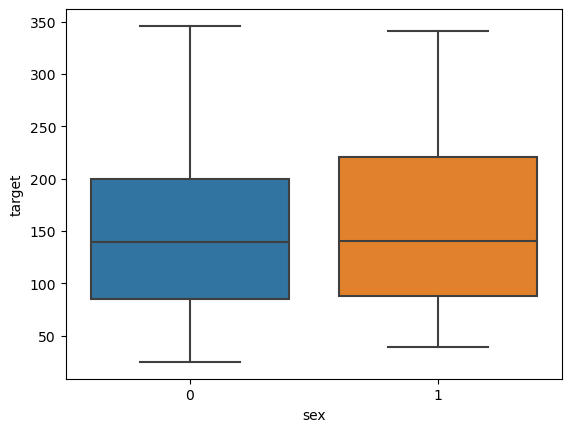

In [39]:
# 12. Looking at the relationship between categorical and target features
sns.boxplot(x=data[categorical_features[0]],y=data[target])

### 13. Looking at the relationship between numeric and target features

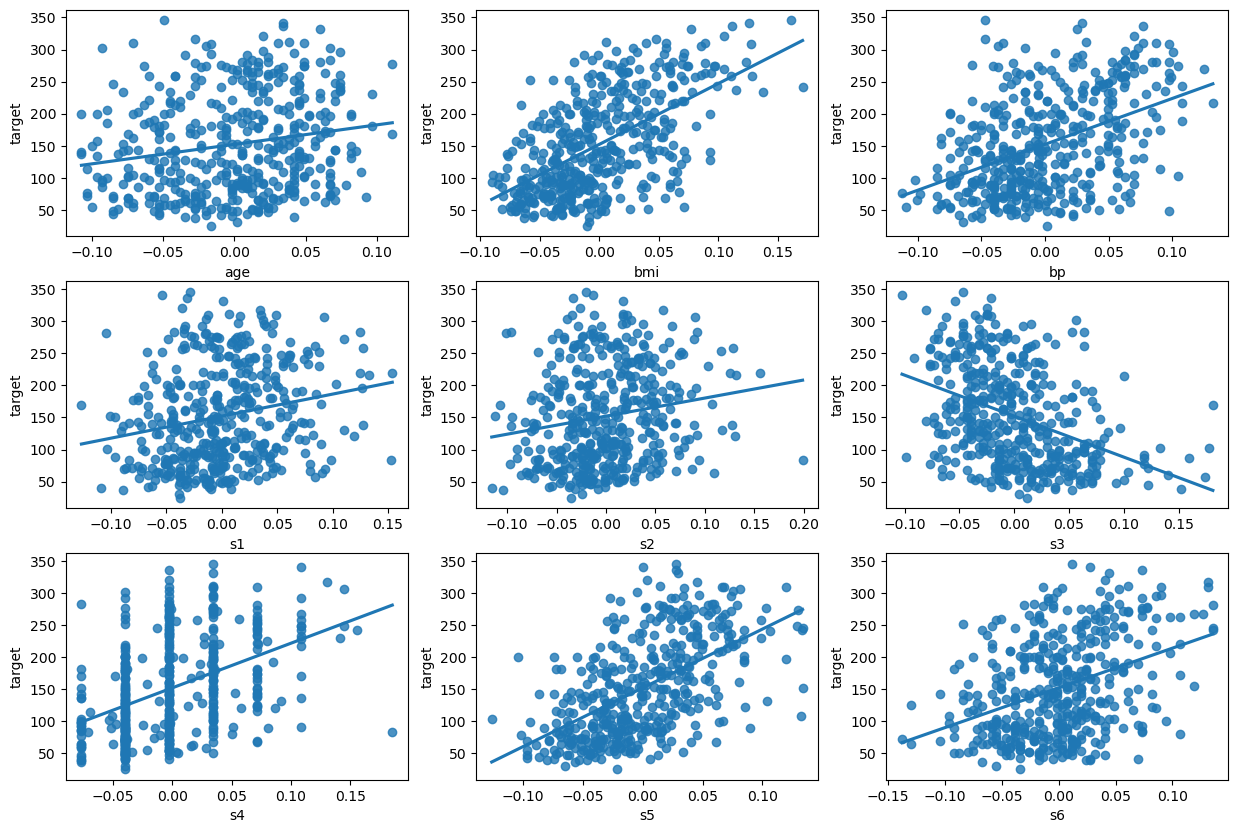

In [40]:
# 13. Looking at the relationship between numeric and target features
fig,ax = plt.subplots(3,3,figsize=(15,10))
row = col = 0
for n,i in enumerate(numeric_features):
    if (n%3 == 0) & (n > 0):
        row += 1
        col = 0
    sns.regplot(x=i,y="target",data=data,ax=ax[row,col],ci=False)
    col += 1

‘bmi’, ‘bp’, and ‘s5’ show a good linear relationship with the target. However, looking at correlation will give us a better idea.

c:\Anaconda3\envs\deep_learning\Lib\site-packages\seaborn\matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


<Axes: >

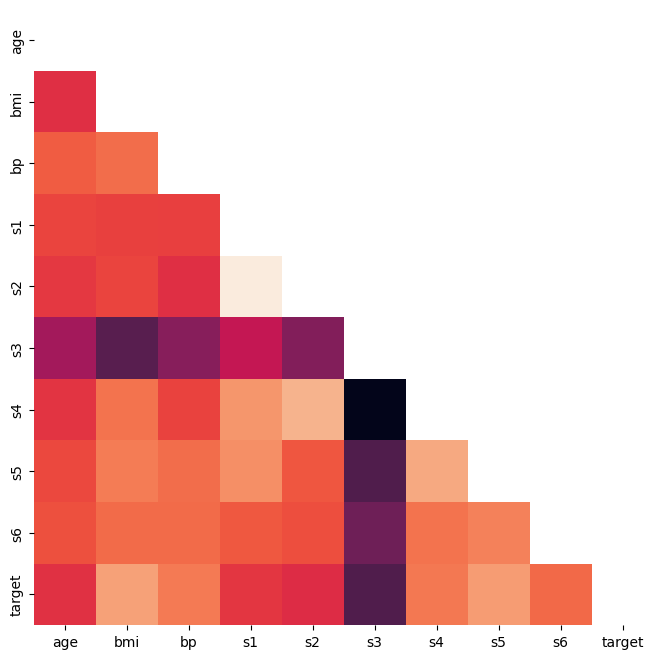

In [41]:
num_tgt = numeric_features.copy() 
num_tgt.append('target')
fig = plt.figure(figsize=(8,8))
sns.heatmap(data[num_tgt].corr(method='pearson'),annot=True,fmt='.2f',mask=np.triu(data[num_tgt].corr(method='pearson')),cbar=False)


c:\Anaconda3\envs\deep_learning\Lib\site-packages\seaborn\matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


<Axes: >

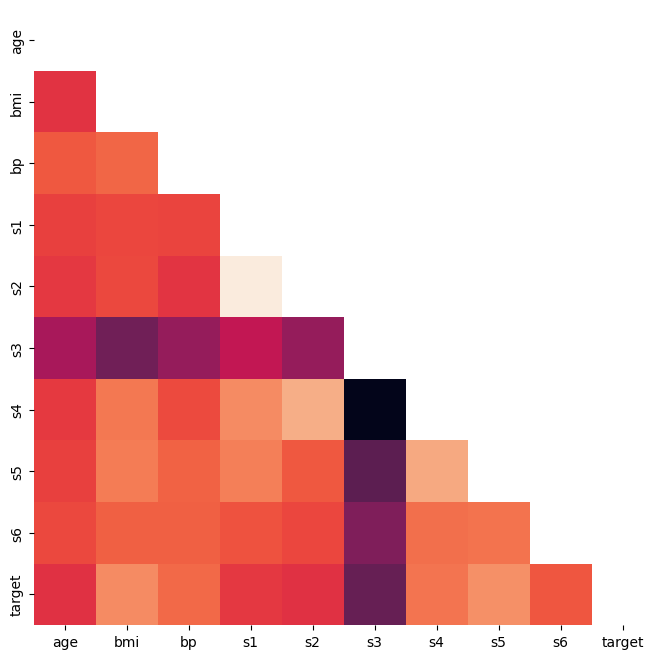

In [42]:
ig = plt.figure(figsize=(8,8))
sns.heatmap(data[num_tgt].corr(method='kendall'),annot=True,fmt='.2f',mask=np.triu(data[num_tgt].corr(method='pearson')),cbar=False)

Source : https://medium.com/mlearning-ai/basic-exploratory-data-analysis-template-for-regression-problems-20ca00c58f7d